In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define column names based on the readme
column_names = [
    'engine_id', 'cycle',
    'setting_1', 'setting_2', 'setting_3',
    's1', 's2', 's3', 's4', 's5',
    's6', 's7', 's8', 's9', 's10',
    's11', 's12', 's13', 's14', 's15',
    's16', 's17', 's18', 's19', 's20', 's21'
]

# Load FD001 training data
df = pd.read_csv(
    '../../data/raw/train_FD001.txt',
    sep=' ',
    header=None,
    names=column_names
)

# Quick look at the data
print(df.shape)
df.head()

(20631, 26)


engine_id   cycle  setting_1  setting_2  setting_3       s1       s2  \
1 1    -0.0007 -0.0004      100.0     518.67     641.82  1589.70  1400.60   
  2     0.0019 -0.0003      100.0     518.67     642.15  1591.82  1403.14   
  3    -0.0043  0.0003      100.0     518.67     642.35  1587.99  1404.20   
  4     0.0007  0.0000      100.0     518.67     642.35  1582.79  1401.87   
  5    -0.0019 -0.0002      100.0     518.67     642.37  1582.85  1406.22   

        s3     s4      s5  ...      s12     s13   s14  s15   s16    s17  \
1 1  14.62  21.61  554.36  ...  8138.62  8.4195  0.03  392  2388  100.0   
  2  14.62  21.61  553.75  ...  8131.49  8.4318  0.03  392  2388  100.0   
  3  14.62  21.61  554.26  ...  8133.23  8.4178  0.03  390  2388  100.0   
  4  14.62  21.61  554.45  ...  8133.83  8.3682  0.03  392  2388  100.0   
  5  14.62  21.61  554.00  ...  8133.80  8.4294  0.03  393  2388  100.0   

       s18      s19  s20  s21  
1 1  39.06  23.4190  NaN  NaN  
  2  39.00  23.4236  NaN  NaN  
  3  38.95  23.3442  NaN  NaN  
  4  38.88  23.3739  NaN  NaN  
  5  38.90  23.4044  NaN  NaN  

[5 rows x 26 columns]

In [3]:
# How many unique engines do we have?
print("Number of engines:", df['engine_id'].nunique())

# How long does each engine run before failure?
engine_life = df.groupby('engine_id')['cycle'].max()
print("\nEngine life stats (cycles):")
print(engine_life.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum().sum())

Number of engines: 158

Engine life stats (cycles):
count    158.000000
mean       0.000443
std        0.000220
min       -0.000400
25%        0.000500
50%        0.000500
75%        0.000600
max        0.000600
Name: cycle, dtype: float64

Missing values:
41262


In [4]:
# Check what data types we have
print(df.dtypes)
print("\nFirst few values of cycle column:")
print(df['cycle'].head(10))

engine_id    float64
cycle        float64
setting_1    float64
setting_2    float64
setting_3    float64
s1           float64
s2           float64
s3           float64
s4           float64
s5           float64
s6           float64
s7           float64
s8           float64
s9           float64
s10          float64
s11          float64
s12          float64
s13          float64
s14          float64
s15            int64
s16            int64
s17          float64
s18          float64
s19          float64
s20          float64
s21          float64
dtype: object

First few values of cycle column:
1  1    -0.0004
   2    -0.0003
   3     0.0003
   4     0.0000
   5    -0.0002
   6    -0.0001
   7     0.0001
   8     0.0003
   9     0.0001
   10    0.0001
Name: cycle, dtype: float64


In [5]:
# Fix: add an extra column name for the phantom empty column
column_names_fixed = [
    'engine_id', 'cycle',
    'setting_1', 'setting_2', 'setting_3',
    's1', 's2', 's3', 's4', 's5',
    's6', 's7', 's8', 's9', 's10',
    's11', 's12', 's13', 's14', 's15',
    's16', 's17', 's18', 's19', 's20', 's21',
    'extra'
]

# Reload with the fix
df = pd.read_csv(
    '../../data/raw/train_FD001.txt',
    sep='\s+',        # handles multiple spaces
    header=None,
    names=column_names_fixed,
    engine='python'
)

# Drop the phantom column
df = df.drop(columns=['extra'])

# Verify
print("Shape:", df.shape)
print("\nEngine count:", df['engine_id'].nunique())
print("\nCycle column sample:")
print(df['cycle'].head())

Shape: (20631, 26)

Engine count: 100

Cycle column sample:
0    1
1    2
2    3
3    4
4    5
Name: cycle, dtype: int64


In [6]:
# How long does each engine run before failure?
engine_life = df.groupby('engine_id')['cycle'].max()

print("Engine life statistics (cycles until failure):")
print(engine_life.describe())

print("\nShortest-lived engine:", engine_life.min(), "cycles")
print("Longest-lived engine:", engine_life.max(), "cycles")

Engine life statistics (cycles until failure):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

Shortest-lived engine: 128 cycles
Longest-lived engine: 362 cycles


In [7]:
# Calculate RUL for each row
# Step 1: find the max cycle (failure point) for each engine
max_cycle_per_engine = df.groupby('engine_id')['cycle'].transform('max')

# Step 2: RUL = failure cycle - current cycle
df['RUL'] = max_cycle_per_engine - df['cycle']

# Look at engine 1's first and last few rows
print("Engine 1 - first 5 rows:")
print(df[df['engine_id'] == 1][['engine_id', 'cycle', 'RUL']].head())

print("\nEngine 1 - last 5 rows:")
print(df[df['engine_id'] == 1][['engine_id', 'cycle', 'RUL']].tail())

Engine 1 - first 5 rows:
   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187

Engine 1 - last 5 rows:
     engine_id  cycle  RUL
187          1    188    4
188          1    189    3
189          1    190    2
190          1    191    1
191          1    192    0


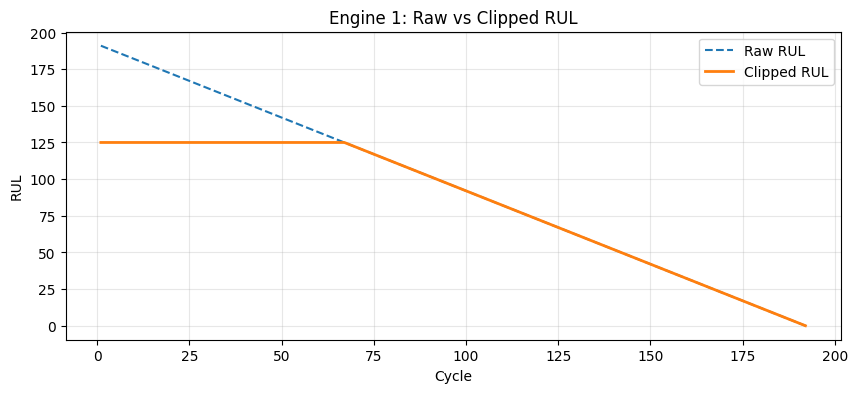

In [8]:
# Apply RUL clipping at 125 cycles
RUL_CAP = 125
df['RUL_clipped'] = df['RUL'].clip(upper=RUL_CAP)

# Compare before and after for engine 1
import matplotlib.pyplot as plt

engine_1 = df[df['engine_id'] == 1]

plt.figure(figsize=(10, 4))
plt.plot(engine_1['cycle'], engine_1['RUL'], label='Raw RUL', linestyle='--')
plt.plot(engine_1['cycle'], engine_1['RUL_clipped'], label='Clipped RUL', linewidth=2)
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('Engine 1: Raw vs Clipped RUL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

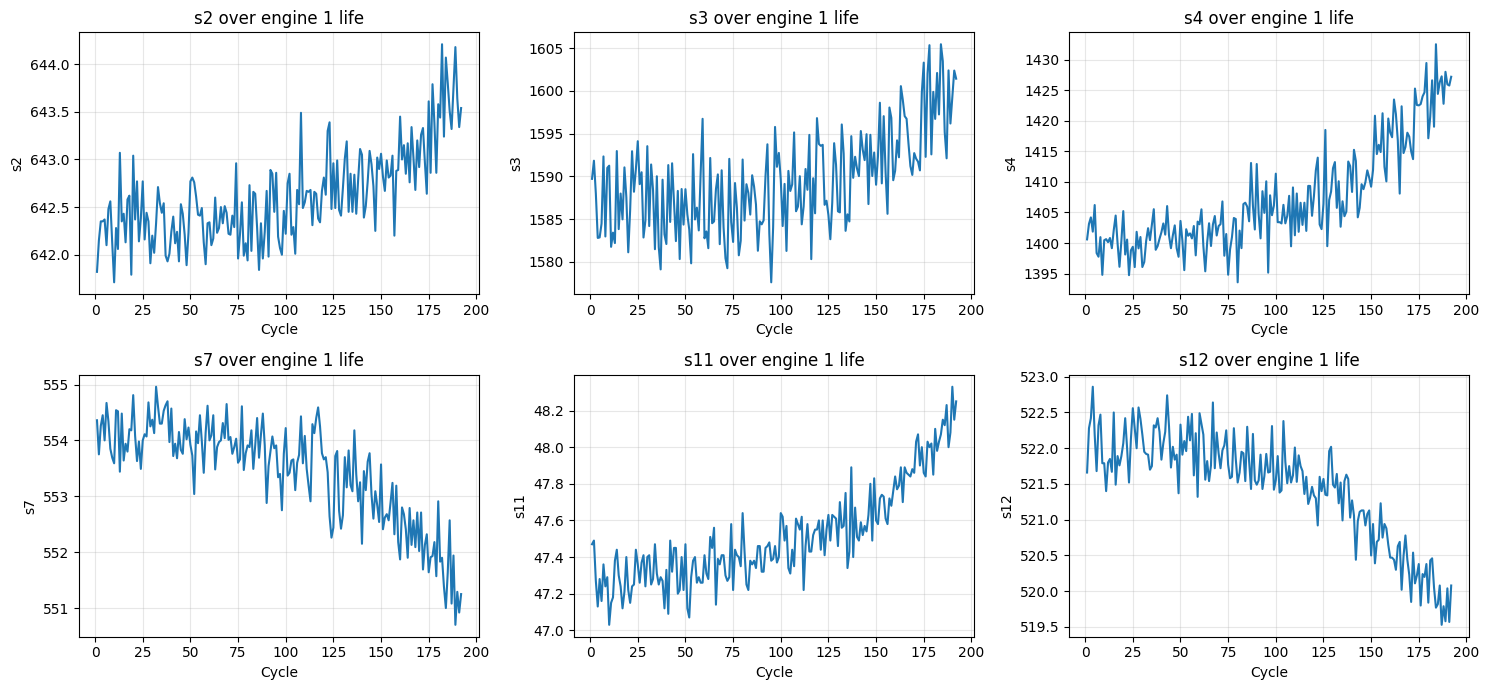

In [9]:
# Plot a few sensors over the life of engine 1 vs its RUL
sensors_to_check = ['s2', 's3', 's4', 's7', 's11', 's12']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_check):
    axes[i].plot(engine_1['cycle'], engine_1[sensor])
    axes[i].set_title(f'{sensor} over engine 1 life')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel(sensor)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Find columns that barely change (low variance = no information)
sensor_cols = [c for c in df.columns if c.startswith('s') and c != 'setting_3']

# Calculate standard deviation of each sensor
stds = df[sensor_cols].std().sort_values()
print("Sensor standard deviations (smallest first):")
print(stds)

Sensor standard deviations (smallest first):
s1           0.000000e+00
s10          0.000000e+00
s19          0.000000e+00
s18          0.000000e+00
s16          3.469531e-18
s5           5.329200e-15
setting_2    2.930621e-04
s6           1.388985e-03
setting_1    2.187313e-03
s15          3.750504e-02
s8           7.098548e-02
s13          7.191892e-02
s21          1.082509e-01
s20          1.807464e-01
s11          2.670874e-01
s2           5.000533e-01
s12          7.375534e-01
s7           8.850923e-01
s17          1.548763e+00
s3           6.131150e+00
s4           9.000605e+00
s14          1.907618e+01
s9           2.208288e+01
dtype: float64


In [11]:
# Sensors and settings with no useful variation
columns_to_drop = ['setting_1', 'setting_2', 'setting_3',
                   's1', 's5', 's6', 's10', 's16', 's18', 's19']

df_clean = df.drop(columns=columns_to_drop)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Original shape: (20631, 28)
Cleaned shape: (20631, 18)

Remaining columns:
['engine_id', 'cycle', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'RUL', 'RUL_clipped']


In [12]:
# Save the cleaned dataset
df_clean.to_csv('../../data/processed/train_FD001_clean.csv', index=False)
print("Saved cleaned data!")

Saved cleaned data!


In [13]:
window_size = 5
window_size

5

In [14]:
sensor_columns = ['s2', 's3', 's4']
df_clean[sensor_columns]

,s2,s3,s4
0,641.82,1589.70,1400.60
1,642.15,1591.82,1403.14
2,642.35,1587.99,1404.20
3,642.35,1582.79,1401.87
4,642.37,1582.85,1406.22
...,...,...,...
20626,643.49,1597.98,1428.63
20627,643.54,1604.50,1433.58
20628,643.42,1602.46,1428.18
20629,643.23,1605.26,1426.53


In [16]:
df_clean['s2'].rolling(window=window_size).mean()

0            NaN
1            NaN
2            NaN
3            NaN
4        642.208
          ...   
20626    643.448
20627    643.450
20628    643.516
20629    643.418
20630    643.506
Name: s2, Length: 20631, dtype: float64

In [17]:
df_clean.groupby('engine_id')['s2'].rolling(window=window_size).mean().reset_index(level=0, drop=True)

0            NaN
1            NaN
2            NaN
3            NaN
4        642.208
          ...   
20626    643.448
20627    643.450
20628    643.516
20629    643.418
20630    643.506
Name: s2, Length: 20631, dtype: float64

In [18]:
# The buggy version (rolls across everything)
rolling_bad = df_clean['s2'].rolling(window=window_size).mean()

# The correct version (resets per engine)
rolling_good = df_clean.groupby('engine_id')['s2'].rolling(window=window_size).mean().reset_index(level=0, drop=True)

# Look at the engine 1 → engine 2 boundary (rows 190 to 196)
print("Rows around the engine 1 / engine 2 boundary:\n")
print("BAD (rolls across engines):")
print(rolling_bad.iloc[190:197])
print("\nGOOD (resets per engine):")
print(rolling_good.iloc[190:197])

Rows around the engine 1 / engine 2 boundary:

BAD (rolls across engines):
190    643.646
191    643.690
192    643.318
193    642.846
194    642.428
195    642.096
196    641.734
Name: s2, dtype: float64

GOOD (resets per engine):
190    643.646
191    643.690
192        NaN
193        NaN
194        NaN
195        NaN
196    641.734
Name: s2, dtype: float64


In [20]:
for sensor in ['s2', 's3', 's4']:
    print(sensor)
    print(df_clean.groupby('engine_id')[sensor].rolling(window=window_size).mean())

s2
engine_id       
1          0            NaN
           1            NaN
           2            NaN
           3            NaN
           4        642.208
                     ...   
100        20626    643.448
           20627    643.450
           20628    643.516
           20629    643.418
           20630    643.506
Name: s2, Length: 20631, dtype: float64
s3
engine_id       
1          0             NaN
           1             NaN
           2             NaN
           3             NaN
           4        1587.030
                      ...   
100        20626    1599.270
           20627    1599.924
           20628    1600.454
           20629    1602.048
           20630    1602.116
Name: s3, Length: 20631, dtype: float64
s4
engine_id       
1          0             NaN
           1             NaN
           2             NaN
           3             NaN
           4        1403.206
                      ...   
100        20626    1427.270
           20627    1430.090
 

In [22]:
for sensor in ['s2', 's3', 's4']:
    df_clean[f'{sensor}_rolling_mean'] = df_clean.groupby('engine_id')[sensor].rolling(window=window_size).mean().reset_index(level=0, drop=True)

In [23]:
df_clean.head()

,engine_id,cycle,s2,s3,s4,s7,s8,s9,s11,s12,...,s14,s15,s17,s20,s21,RUL,RUL_clipped,s2_rolling_mean,s3_rolling_mean,s4_rolling_mean
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,...,8138.62,8.4195,392,39.06,23.4190,191,125,NaN,NaN,NaN
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,...,8131.49,8.4318,392,39.00,23.4236,190,125,NaN,NaN,NaN
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,...,8133.23,8.4178,390,38.95,23.3442,189,125,NaN,NaN,NaN
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,...,8133.83,8.3682,392,38.88,23.3739,188,125,NaN,NaN,NaN
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,...,8133.80,8.4294,393,38.90,23.4044,187,125,642.208,1587.03,1403.206


In [24]:
# Build the list of sensor columns automatically
sensor_columns = [col for col in df_clean.columns 
                  if col.startswith('s') 
                  and not col.endswith('_rolling_mean')
                  and col not in ['setting_1', 'setting_2', 'setting_3']]

print(sensor_columns)
print("Count:", len(sensor_columns))

['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Count: 14


In [25]:
for sensor in sensor_columns:
    df_clean[f'{sensor}_rolling_mean'] = df_clean.groupby('engine_id')[sensor].rolling(window=window_size).mean().reset_index(level=0, drop=True)

In [26]:
print("Total colums now:", df_clean.shape[1])
df_clean.columns.tolist()

Total colums now: 32


['engine_id',
 'cycle',
 's2',
 's3',
 's4',
 's7',
 's8',
 's9',
 's11',
 's12',
 's13',
 's14',
 's15',
 's17',
 's20',
 's21',
 'RUL',
 'RUL_clipped',
 's2_rolling_mean',
 's3_rolling_mean',
 's4_rolling_mean',
 's7_rolling_mean',
 's8_rolling_mean',
 's9_rolling_mean',
 's11_rolling_mean',
 's12_rolling_mean',
 's13_rolling_mean',
 's14_rolling_mean',
 's15_rolling_mean',
 's17_rolling_mean',
 's20_rolling_mean',
 's21_rolling_mean']

In [30]:
for sensor in sensor_columns:
    df_clean[f'{sensor}_rolling_std'] = df_clean.groupby('engine_id')[sensor].rolling(window=window_size).std().reset_index(level=0, drop=True)

In [31]:
print("Total columns now:", df_clean.shape[1])

Total columns now: 46


In [32]:
df_clean.to_csv('../../data/processed/train_FD001_features.csv', index=False)
print("Saved! Shape:", df_clean.shape)

Saved! Shape: (20631, 46)
